# 04. EDA, 가설 검증과 후속 실험

[문제 정의와 가설](01_problem_hypothesis.md)에서 출발한다. 최초 조회 후 30일을 완전히 관찰할 수 있는 동일 사용자×상품에서 View → Cart → Purchase 퍼널을 확인하고, 대표 첫 구매 중 이 경로로 포착되는 규모를 판단한다. 이어 대표 첫 구매를 다섯 경로로 나누고, 별도 최초 cart 미구매 집단의 구매 시점을 살펴 후속 실험을 설계한다.

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display
from dotenv import load_dotenv
from sqlalchemy import URL, create_engine

PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / 'cache_context.json').is_file() and (p / 'sql').is_dir())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from query_cache import QueryCache

load_dotenv(PROJECT_ROOT / '.env')
required_env = ('DB_USER', 'DB_PASSWORD', 'DB_HOST', 'DB_PORT', 'DB_NAME')
if any(not os.getenv(k) for k in required_env):
    raise RuntimeError('캐시 출처 확인용 .env 항목이 부족하다.')
# Engine은 DB 출처 식별에만 사용한다. 캐시 조회는 DB에 연결하지 않는다.
engine = create_engine(URL.create(
    'mysql+pymysql', username=os.environ['DB_USER'], password=os.environ['DB_PASSWORD'],
    host=os.environ['DB_HOST'], port=int(os.environ['DB_PORT']), database=os.environ['DB_NAME'],
))
COMPATIBILITY_FILE = PROJECT_ROOT / 'sql' / 'cache_compatibility.json'

FINAL_CACHE = QueryCache(
    engine=engine, sql_file=PROJECT_ROOT / 'sql' / 'eda.sql',
    upstream_sql_files=(), cache_dir=PROJECT_ROOT / 'cache',
    context_file=PROJECT_ROOT / 'cache_context.json',
)
def read_eda(name, **kwargs):
    return FINAL_CACHE.read_compatible_cached(
        name, compatibility_file=COMPATIBILITY_FILE, **kwargs
    )
import json
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = 'plotly_mimetype'
COLORS = {'view':'#3B82F6','cart':'#F59E0B','purchase':'#10B981',
          'attention':'#EF4444','neutral':'#94A3B8'}


---
## 1. 가설 1 — 한 세션의 View → Cart → Purchase만 보면 동일 상품 구매의 상당 부분을 포착하지 못할 것이다

<strong>가설 1:</strong> 한 세션의 View → Cart → Purchase만 보면 동일 상품 구매의 상당 부분을 포착하지 못할 것이다.

### 1-1. 같은 30일 적격군에서 View → Cart → Purchase는 얼마나 이어지는가?

최초 동일 상품 View 이후 30일을 끝까지 관찰할 수 있는 사용자×상품을 한 번씩 센다. Cart 단계는 같은 세션에서 동일 상품 View보다 늦은 Cart가 확인된 경우다. 대표 첫 구매가 있다면 그 구매보다 앞선 Cart만 포함하고, 구매가 없다면 최초 View 후 30일 안의 Cart를 포함한다. Purchase 단계는 대표 첫 구매까지 같은 세션에서 View → Cart → Purchase가 순서대로 이어진 경우다.

In [2]:
cohort = read_eda('pj_30day_purchase_cohort').iloc[0]
mart_paths = read_eda('pj_representative_purchase_mart')

# 187건 경계 키·파라미터를 만들고 검증된 제한 조회 캐시만 읽는다.
boundary_keys = mart_paths.loc[
    mart_paths['row_type'].eq('raw 확인 경계'),
    ['user_id', 'product_id', 'anchor_view_at', 'boundary_type'],
].copy()
boundary_keys['user_id'] = boundary_keys['user_id'].astype('int64')
boundary_keys['product_id'] = boundary_keys['product_id'].astype('int64')
boundary_keys['anchor_view_at'] = pd.to_datetime(boundary_keys['anchor_view_at']).dt.strftime('%Y-%m-%d %H:%M:%S')
boundary_json = json.dumps(boundary_keys.to_dict('records'), ensure_ascii=False, separators=(',', ':'))
raw_paths = read_eda('pj_boundary_raw_paths', params={'boundary_json': boundary_json})

eligible_30day = int(cohort['관측가능30일_사용자상품수'])
representative = int(cohort['마트확정_대표첫구매_사용자상품수']) + int((
    raw_paths['boundary_type'].eq('대표 구매 시각 경계')
    & raw_paths['eligible_purchase_flag'].eq(1)
).sum())
confirmed = mart_paths.loc[mart_paths['row_type'].eq('마트 확정 경로')]
raw_classified = raw_paths.loc[raw_paths['eligible_purchase_flag'].eq(1) & raw_paths['path_order'].notna()]
path_counts = confirmed.groupby('path_order').size().add(raw_classified.groupby('path_order').size(), fill_value=0)
same_session = int(path_counts.get(float(1), 0))
outside = representative - same_session
assert len(boundary_keys) == len(raw_paths) == 187
assert raw_paths['eligible_purchase_flag'].eq(1).all() and raw_paths['path_order'].notna().all()
assert (eligible_30day, representative, same_session, outside) == (5_323_764, 342_457, 103_974, 238_483)
# 30일 적격군의 같은 세션 View→Cart 단계만 기존 마트에서 제한 집계했다.
# 마트 시각으로 확정된 683,751개 + 관련 이벤트만 확인한 경계 66개 중 적격 43개.
cart_after_view_30d = 683_751 + 43
assert 43 + 23 == 66
assert (eligible_30day, cart_after_view_30d, same_session) == (5_323_764, 683_794, 103_974)
assert same_session <= cart_after_view_30d <= eligible_30day
funnel_table = pd.DataFrame({
    '동일 상품의 행동 단계': [
        'View · 30일 완전 관측',
        '같은 세션 View 이후 Cart',
        '같은 세션 View → Cart → 대표 첫 구매',
    ],
    '사용자×상품 조합 수': [eligible_30day, cart_after_view_30d, same_session],
    '직전 단계 분모': [eligible_30day, eligible_30day, cart_after_view_30d],
    '직전 단계 도달률 (%)': [
        100,
        cart_after_view_30d / eligible_30day * 100,
        same_session / cart_after_view_30d * 100,
    ],
    'View 적격군 기준 누적 비율 (%)': [
        100,
        cart_after_view_30d / eligible_30day * 100,
        same_session / eligible_30day * 100,
    ],
})
display(funnel_table.round(3))

[pj_30day_purchase_cohort] cache HIT 503148ef8f8e · 1행
[pj_representative_purchase_mart] cache HIT e446dce2ac5d · 342,457행
[pj_boundary_raw_paths] cache HIT 84e5f7054019 · 187행


,동일 상품의 행동 단계,사용자×상품 조합 수,직전 단계 분모,직전 단계 도달률 (%),View 적격군 기준 누적 비율 (%)
0,View · 30일 완전 관측,5323764,5323764,100.000,100.000
1,같은 세션 View 이후 Cart,683794,5323764,12.844,12.844
2,같은 세션 View → Cart → 대표 첫 구매,103974,683794,15.205,1.953


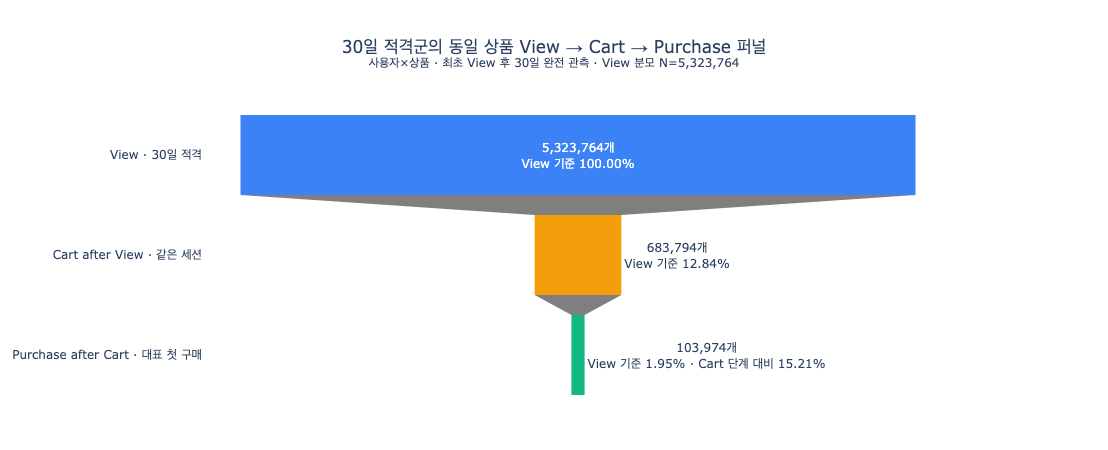

In [3]:
funnel_counts = [eligible_30day, cart_after_view_30d, same_session]
funnel_labels = [
    'View · 30일 적격',
    'Cart after View · 같은 세션',
    'Purchase after Cart · 대표 첫 구매',
]
funnel_text = [
    f'{eligible_30day:,}개<br>View 기준 100.00%',
    f'{cart_after_view_30d:,}개<br>View 기준 {cart_after_view_30d / eligible_30day * 100:.2f}%',
    f'{same_session:,}개<br>View 기준 {same_session / eligible_30day * 100:.2f}% · Cart 단계 대비 {same_session / cart_after_view_30d * 100:.2f}%',
]
fig = go.Figure(go.Funnel(
    y=funnel_labels, x=funnel_counts,
    text=funnel_text, textinfo='text',
    marker=dict(color=[COLORS['view'], COLORS['cart'], COLORS['purchase']]),
))
fig.update_layout(
    title=dict(text=f'30일 적격군의 동일 상품 View → Cart → Purchase 퍼널<br><sup>사용자×상품 · 최초 View 후 30일 완전 관측 · View 분모 N={eligible_30day:,}</sup>', x=0.5),
    paper_bgcolor='white', plot_bgcolor='white', height=450,
    margin=dict(l=150, r=155, t=105, b=45),
)
fig.show()

30일 적격 사용자×상품 5,323,764개 중 같은 세션에서 동일 상품 View 이후 Cart가 확인된 조합은 683,794개(12.844%)다. 그중 대표 첫 구매까지 한 세션의 View → Cart → Purchase로 이어진 조합은 103,974개로, Cart 단계의 15.205%이자 전체 View 적격군의 1.953%다.

각 단계의 이탈을 보기 위해 단계별 도달률은 직전 단계에 도달한 사용자×상품을 분모로 사용하고, 전체 누적 비율은 최초 View 적격군을 기준으로 계산했다.

### 1-2. 실제 대표 첫 구매 중 한 세션의 완결 경로는 얼마나 포착하는가?

같은 30일 적격군에서 대표 첫 구매가 확인된 사용자×상품은 342,457개(적격군의 6.433%)다. 이제 그 구매를 분모로 놓고, 위 퍼널의 최종 단계에 해당하는 한 세션 View → Cart → Purchase와 그 밖의 구매를 구분한다.

In [4]:
purchase_coverage = pd.DataFrame({
    '대표 첫 구매의 한 세션 경로': [
        'View → Cart → Purchase 모두 이어짐',
        'View → Cart → Purchase 모두 이어지지 않음',
    ],
    '조합 수': [same_session, outside],
    '공통 분모: 대표 첫 구매': [representative, representative],
    '대표 첫 구매 내 비중 (%)': [
        same_session / representative * 100,
        outside / representative * 100,
    ],
})
assert same_session + outside == representative
display(purchase_coverage.round(3))

,대표 첫 구매의 한 세션 경로,조합 수,공통 분모: 대표 첫 구매,대표 첫 구매 내 비중 (%)
0,View → Cart → Purchase 모두 이어짐,103974,342457,30.361
1,View → Cart → Purchase 모두 이어지지 않음,238483,342457,69.639


대표 첫 구매 342,457개 중 한 세션에서 View → Cart → Purchase가 모두 이어진 구매는 103,974개(30.361%)였다. 나머지 238,483개(69.639%)는 이 완결 경로로 포착되지 않았다. 69.639%가 모두 다른 세션에서 구매했다는 뜻은 아니다.

같은 30일 적격 사용자×상품을 분모로 한 1.953%와 6.433%는 직접 나란히 볼 수 있다. 다만 두 비율의 차이 전체가 세션 경계 효과는 아니다. 한 세션 완결 경로에는 Cart를 거쳐야 한다는 조건도 있기 때문이다.

### 1-3. 가설 1 판단

대표 첫 구매 342,457개 중 한 세션에서 View → Cart → Purchase가 모두 이어진 구매는 103,974개(30.361%)였다. 나머지 238,483개(69.639%)는 이 완결 경로만으로는 포착되지 않아, 한 세션의 순차 퍼널만으로 실제 동일 상품 구매 여정을 설명하는 데 한계가 있었다.

---
## 2. 가설 2 — 동일 상품의 구매 경로 중 이전 세션 Cart와 연결된 경로가 가장 큰 비중을 차지할 것이다

<strong>가설 2:</strong> 동일 상품의 구매 경로 중 이전 세션 Cart와 연결된 경로가 가장 큰 비중을 차지할 것이다.

가설 1에서 View → Cart → Purchase가 한 세션에서 모두 이어지지 않은 대표 첫 구매 238,483개를 확인했다. 이제 <strong>같은 30일 대표 첫 구매 342,457개</strong>를 그대로 분모로 두고 다섯 구매 경로를 비교한다.

### 2-1. 대표 첫 구매는 어떤 경로로 나타나는가?

최초 조회 이후 30일 안의 가장 이른 동일 상품 구매만 대표로 삼고, 그보다 뒤의 재구매는 제외한다. 기존 ‘구매 전 담기 미확인’ 경로는 구매 세션의 선행 View가 확인되는지에 따라 나눠, 대표 첫 구매 하나가 다섯 경로 중 하나에만 들어가도록 한다.

In [5]:
# 담기 미확인 110,515개만 기존 마트·원본 경계에서 제한 검증한 집계.
# 대표 구매 세션의 첫 purchase 이전 View를 strict 시각 순서로 확인했다.
# 마트 확정 110,454개: 구매 세션 View→Purchase 57,620 / Purchase only 52,834.
# 원본 경계 61개: 구매 세션 View→Purchase 59 / Purchase only 2.
no_cart_view_purchase = 57_620 + 59
no_cart_purchase_only = 52_834 + 2
assert 57_620 + 52_834 == 110_454 and 59 + 2 == 61
assert no_cart_view_purchase + no_cart_purchase_only == int(path_counts.get(float(4), 0)) == 110_515
path_labels = {
    1: '같은 세션 View → Cart → Purchase',
    2: '같은 세션 Cart → Purchase · 앞선 View 미확인',
    3: '이전 세션 Cart → 대표 첫 구매',
    4: '담기 미확인 · 구매 세션 View → Purchase',
    5: '담기 미확인 · 구매 세션 Purchase only',
}
path_values = [
    int(path_counts.get(float(1), 0)),
    int(path_counts.get(float(2), 0)),
    int(path_counts.get(float(3), 0)),
    no_cart_view_purchase,
    no_cart_purchase_only,
]
paths = pd.DataFrame({'경로': [path_labels[i] for i in range(1, 6)], '조합 수': path_values})
paths['분모: 대표 첫 구매'] = representative
paths['대표 첫 구매 내 비중 (%)'] = paths['조합 수'] / representative * 100
assert paths['조합 수'].tolist() == [103_974, 14_291, 113_677, 57_679, 52_836]
assert paths['조합 수'].sum() == representative
assert paths['조합 수'].iloc[1:].sum() == outside
assert paths['조합 수'].iloc[-2:].sum() == 110_515
same_session_cart_n = int(paths['조합 수'].iloc[:2].sum())
prior_session_cart_n = int(paths['조합 수'].iloc[2])
no_cart_observed_n = int(paths['조합 수'].iloc[3:].sum())
other_paths_n = representative - prior_session_cart_n
assert (same_session_cart_n, prior_session_cart_n, no_cart_observed_n, other_paths_n) == (
    118_265, 113_677, 110_515, 228_780,
)
assert same_session_cart_n + no_cart_observed_n == other_paths_n
display(paths.round(3))

,경로,조합 수,분모: 대표 첫 구매,대표 첫 구매 내 비중 (%)
0,같은 세션 View → Cart → Purchase,103974,342457,30.361
1,같은 세션 Cart → Purchase · 앞선 View 미확인,14291,342457,4.173
2,이전 세션 Cart → 대표 첫 구매,113677,342457,33.195
3,담기 미확인 · 구매 세션 View → Purchase,57679,342457,16.843
4,담기 미확인 · 구매 세션 Purchase only,52836,342457,15.429


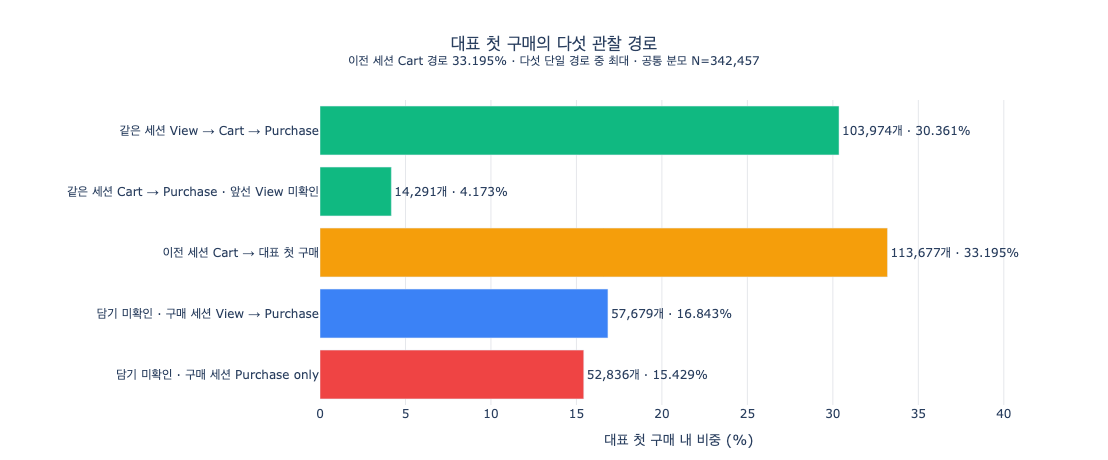

In [6]:
fig = go.Figure(go.Bar(
    x=paths['대표 첫 구매 내 비중 (%)'], y=paths['경로'], orientation='h',
    marker_color=[COLORS['purchase'], COLORS['purchase'], COLORS['cart'], COLORS['view'], COLORS['attention']],
    text=[f"{n:,}개 · {p:.3f}%" for n, p in zip(paths['조합 수'], paths['대표 첫 구매 내 비중 (%)'])],
    textposition='outside', cliponaxis=False,
    hovertemplate='%{y}<br>%{text}<extra></extra>',
))
fig.update_layout(
    title=dict(text=f'대표 첫 구매의 다섯 관찰 경로<br><sup>이전 세션 Cart 경로 {prior_session_cart_n / representative * 100:.3f}% · 다섯 단일 경로 중 최대 · 공통 분모 N={representative:,}</sup>', x=0.5),
    xaxis=dict(title='대표 첫 구매 내 비중 (%)', range=[0, 42], gridcolor='#E5E7EB'),
    yaxis=dict(autorange='reversed'), paper_bgcolor='white', plot_bgcolor='white',
    height=460, margin=dict(l=320, r=70, t=100, b=55),
)
fig.show()

다섯 경로의 합은 대표 첫 구매 342,457개다. 이전 세션 Cart → 대표 첫 구매가 113,677개(33.195%)로 가장 큰 단일 경로였다. 한 세션 View → Cart → Purchase도 103,974개(30.361%)로 비슷한 수준이었다. 나머지는 같은 세션 Cart → Purchase·앞선 View 미확인 14,291개(4.173%), 담기 미확인·구매 세션 View → Purchase 57,679개(16.843%), 담기 미확인·구매 세션 Purchase only 52,836개(15.429%)였다.

담기 미확인은 로그에서 구매 전 Cart가 확인되지 않았다는 뜻이다. Purchase only도 최초 조회 이후 30일 적격군에 속하므로 이전에 같은 상품을 조회한 적은 있다. 이 경로 구성비는 이미 구매한 조합을 분모로 하며, 미구매 알림 대상의 구매 확률이나 알림 효과를 뜻하지 않는다.

### 2-2. 가설 2 판단

이전 세션 Cart → 대표 첫 구매 경로가 113,677개(33.195%)로 다섯 경로 중 가장 큰 단일 경로여서 관찰 결과는 가설 2를 지지했다. 다만 같은 세션 View → Cart → Purchase도 103,974개(30.361%)로 비슷한 수준이어서 특정 경로가 압도적으로 지배적이라고 보기는 어렵다. 이는 이미 구매한 조합의 경로 구성비이며, 미구매 알림 대상의 구매율이나 알림 효과가 아니다.

---
## 3. 후속 분석 — 최초 cart 이후 구매는 언제 집중되는가?

앞에서는 이미 발생한 구매의 경로를 살펴봤다. 이제 실제 알림 대상을 정하기 위해 최초 cart 후 같은 상품을 아직 구매하지 않은 집단을 별도로 구성한다. cart 이후 7일을 끝까지 관찰할 수 있는 사용자×상품에서 시간 구간별 자연 구매율을 확인하며, 각 구간은 시작 시점의 미구매 조합을 분모로 삼는다.

In [7]:
cart_boundary = read_eda('pj_cart_purchase_boundaries').copy()
cart_boundary['user_id'] = cart_boundary['user_id'].astype('int64')
cart_boundary['product_id'] = cart_boundary['product_id'].astype('int64')
cart_boundary['cart_anchor_at'] = pd.to_datetime(cart_boundary['cart_anchor_at']).dt.strftime('%Y-%m-%d %H:%M:%S')
cart_boundary_json = json.dumps(cart_boundary.to_dict('records'), ensure_ascii=False, separators=(',', ':'))
cart_raw = read_eda('pj_cart_boundary_raw_next_purchase', params={'cart_boundary_json': cart_boundary_json})
corrections = [{
    'user_id': int(row.user_id), 'product_id': int(row.product_id),
    'cart_anchor_at': pd.Timestamp(row.cart_anchor_at).strftime('%Y-%m-%d %H:%M:%S'),
    'next_purchase_at': None if pd.isna(row.next_purchase_at) else pd.Timestamp(row.next_purchase_at).strftime('%Y-%m-%d %H:%M:%S'),
} for row in cart_raw.itertuples(index=False)]
correction_json = json.dumps(corrections, ensure_ascii=False, separators=(',', ':'))
cart_params = {'cart_boundary_corrections_json': correction_json}
rates = read_eda('pj_cart_purchase_next_24h_rate', params=cart_params).sort_values('구간순서')
first_two = rates.iloc[:2].copy()
first_two['조건부 구매율 (%)'] = (
    first_two['다음24시간_구매_사용자상품수'] / first_two['구간시작_미구매_사용자상품수'] * 100
)
cart_7day = int(first_two.iloc[0]['구간시작_미구매_사용자상품수'])
first_day_nonpurchase = int(first_two.iloc[1]['구간시작_미구매_사용자상품수'])
first_day_buy = int(first_two.iloc[0]['다음24시간_구매_사용자상품수'])
second_day_buy = int(first_two.iloc[1]['다음24시간_구매_사용자상품수'])
assert len(cart_boundary) == len(cart_raw) == 129
assert (cart_7day, first_day_nonpurchase, first_day_buy, second_day_buy) == (4_082_470, 3_305_169, 777_301, 53_646)
assert cart_7day - first_day_buy == first_day_nonpurchase
timing = pd.DataFrame({
    '최초 cart 이후 구간': ['0-24시간', '24-48시간'],
    '동일 상품 구매 조합': [first_day_buy, second_day_buy],
    '구간 시작 미구매 조합': [cart_7day, first_day_nonpurchase],
    '조건부 구매율 (%)': [first_day_buy / cart_7day * 100, second_day_buy / first_day_nonpurchase * 100],
})
display(timing.assign(**{'조건부 구매율 (%)': timing['조건부 구매율 (%)'].map(lambda x: f'{x:.3f}')}))

[pj_cart_purchase_boundaries] cache HIT 5ddc669864da · 129행
[pj_cart_boundary_raw_next_purchase] cache HIT 463ab76ba565 · 129행
[pj_cart_purchase_next_24h_rate] cache HIT 1f09cc930bb4 · 7행


,최초 cart 이후 구간,동일 상품 구매 조합,구간 시작 미구매 조합,조건부 구매율 (%)
0,0-24시간,777301,4082470,19.040
1,24-48시간,53646,3305169,1.623


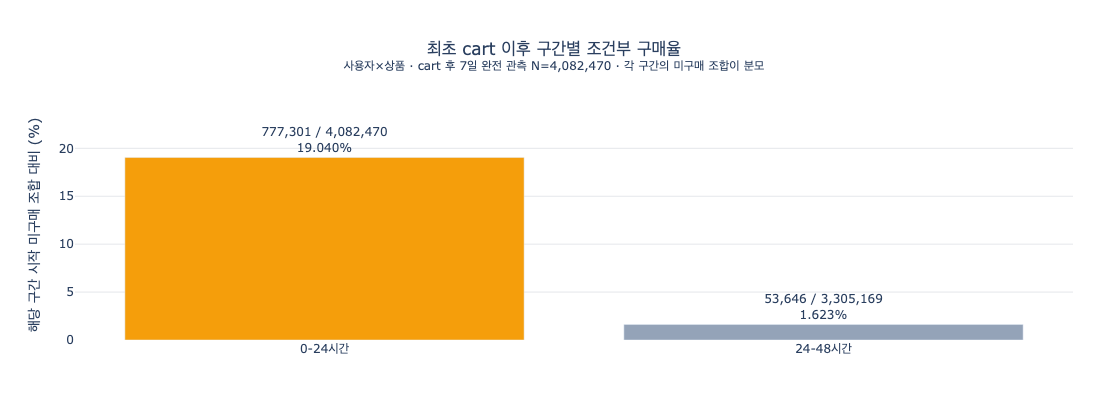

In [8]:
fig = go.Figure(go.Bar(
    x=timing['최초 cart 이후 구간'], y=timing['조건부 구매율 (%)'],
    marker_color=[COLORS['cart'], COLORS['neutral']],
    text=[f"{n:,} / {d:,}<br>{p:.3f}%" for n, d, p in zip(timing['동일 상품 구매 조합'], timing['구간 시작 미구매 조합'], timing['조건부 구매율 (%)'])],
    textposition='outside', cliponaxis=False,
    hovertemplate='%{x}<br>%{text}<extra></extra>',
))
fig.update_layout(
    title=dict(text=f'최초 cart 이후 구간별 조건부 구매율<br><sup>사용자×상품 · cart 후 7일 완전 관측 N={cart_7day:,} · 각 구간의 미구매 조합이 분모</sup>', x=0.5),
    yaxis=dict(title='해당 구간 시작 미구매 조합 대비 (%)', range=[0, 24], gridcolor='#E5E7EB'),
    paper_bgcolor='white', plot_bgcolor='white', height=400,
    margin=dict(l=75, r=35, t=110, b=60),
)
fig.show()

In [9]:
baseline_daily = read_eda('pj_experiment_baseline', params=cart_params)
experiment_eligible = int(baseline_daily['실험적격_사용자상품수'].sum())
experiment_purchase = int(baseline_daily['기준점후_7일_동일상품구매_사용자상품수'].sum())
assert (experiment_eligible, experiment_purchase) == (3_287_385, 154_517)
assert experiment_eligible <= first_day_nonpurchase
baseline = pd.DataFrame({
    '별도 실험 기준선 모집단': ['cart+24시간까지 동일 상품 미구매 · 이후 7일 완전 관측'],
    '이후 7일 동일 상품 구매 조합': [experiment_purchase],
    '적격 사용자×상품 조합': [experiment_eligible],
    '자연 구매 기준선 (%)': [f'{experiment_purchase / experiment_eligible * 100:.3f}'],
})
display(baseline)

[pj_experiment_baseline] cache HIT da088b64f42d · 144행


,별도 실험 기준선 모집단,이후 7일 동일 상품 구매 조합,적격 사용자×상품 조합,자연 구매 기준선 (%)
0,cart+24시간까지 동일 상품 미구매 · 이후 7일 완전 관측,154517,3287385,4.700


최초 cart 후 0–24시간 구매는 777,301 / 4,082,470개(19.040%)였다. 첫 24시간 미구매 조합의 24–48시간 조건부 구매는 53,646 / 3,305,169개(1.623%)다. 알림 실험의 자연 구매 기준선 4.700%는 cart+24시간까지 동일 상품을 사지 않았고 이후 7일을 추가로 관측할 수 있는 별도 적격 조합 154,517 / 3,287,385개에서 계산했다. 세 비율은 분모와 관측 종료 시점이 다르다.

첫날 이후 낮아진 자연 구매 신호를 근거로 24시간을 첫 A/B 테스트 후보 시점으로 삼는다. 이 관찰만으로 최적 발송 시점이나 알림 효과를 판단할 수 없다.

---
## 4. 최종 제안 및 A/B 테스트 설계

후속 분석에서 정한 첫 후보 시점에 맞춰, 최초 cart 후 <strong>24시간까지 동일 상품을 구매하지 않은 사용자</strong>에게 장바구니 알림을 보내는 실험을 제안한다. 이 대상은 앞의 대표 첫 구매자에서 뽑지 않는다. 자연 구매 기준선은 미발송 상태의 관찰값이며, 알림 효과는 실험으로 검증해야 한다.

- <strong>배정·처리:</strong> `user_id` 단위 1:1 무작위 배정. 처리군에는 사용자당 한 번 알리고, 적격 상품이 여러 개면 한 알림에 묶는다. 대조군은 발송하지 않는다.
- <strong>주지표:</strong> 기준 시점 후 7일 내 동일 상품을 구매한 적격 `user_id × product_id` 조합 수 / 전체 적격 조합 수. 사용자별 여러 조합은 군집 표준오차로 처리한다.
- <strong>운영 조건:</strong> 실제 발송 전 수신 동의·장바구니 잔존·재고를 확인한다.
- <strong>가드레일:</strong> 수신 거부·신고, 사용자당 전체 구매 건수·전체 매출. 30일 동일 상품 구매율은 보조지표다.

아래 표는 상대 MDE +5%, ICC 약 0.2308, 사용자당 보정 조합 수 약 9.36, 설계효과 약 2.93을 반영한 표본 계산이다. 보정 후 필요한 표본은 약 763,479개 적격 조합, 예상 모집 기간은 약 41–45일이다. 관찰된 유입과 구매율을 이용한 설계 추정치이며 실제 처리 효과는 관찰되지 않았다.

In [10]:
# 검증된 집계 캐시에 표본·군집 보정 산식을 적용한다. DB 쿼리는 없다.
experiment_daily = baseline_daily.copy()
experiment_daily['실험적격일'] = pd.to_datetime(experiment_daily['실험적격일'])
experiment_eligible_n = int(experiment_daily['실험적격_사용자상품수'].sum())
purchase_7day_n = int(experiment_daily['기준점후_7일_동일상품구매_사용자상품수'].sum())
baseline_rate = purchase_7day_n / experiment_eligible_n
assert (experiment_eligible_n,purchase_7day_n)==(3_287_385,154_517)
# 기존 설계의 1:1 양측 두 비율 표본 산식과 28일 이동평균 하위 사분위를 적용한다.
import math
from statistics import NormalDist

daily_pairs = experiment_daily.groupby('실험적격일')['실험적격_사용자상품수'].sum().sort_index()
daily_pairs = daily_pairs.reindex(pd.date_range(daily_pairs.index.min(), daily_pairs.index.max(), freq='D'), fill_value=0)
rolling_28day = daily_pairs.rolling(window=28, min_periods=28).mean().dropna()
average_daily_pairs = float(daily_pairs.mean())
conservative_daily_pairs = float(rolling_28day.quantile(0.25))
target_rate = baseline_rate * 1.05
pooled_rate = (baseline_rate + target_rate) / 2
z_alpha = NormalDist().inv_cdf(1 - 0.05 / 2)
z_power = NormalDist().inv_cdf(0.80)
per_group = math.ceil((
    z_alpha * math.sqrt(2 * pooled_rate * (1 - pooled_rate))
    + z_power * math.sqrt(baseline_rate * (1 - baseline_rate) + target_rate * (1 - target_rate))
) ** 2 / (target_rate - baseline_rate) ** 2)
independent_pairs = per_group * 2
assert independent_pairs == 260_662
cluster = read_eda('pj_experiment_user_cluster', params=cart_params)
users = cluster['사용자수'].astype('int64')
sizes = cluster['보유_사용자상품수'].astype('int64')
buys = cluster['구매_사용자상품수'].fillna(0).astype('int64')
assert (buys <= sizes).all()
user_n = int(users.sum())
pair_n = int((users*sizes).sum())
assert pair_n==experiment_eligible_n
grand_rate = float((users*buys).sum()/pair_n)
user_rate = buys/sizes
ms_between = float((users*sizes*(user_rate-grand_rate)**2).sum())/(user_n-1)
ms_within = float((users*sizes*user_rate*(1-user_rate)).sum())/(pair_n-user_n)
adjusted_size = (pair_n-float((users*sizes**2).sum())/pair_n)/(user_n-1)
icc = max(0.0,(ms_between-ms_within)/(ms_between+(adjusted_size-1)*ms_within))
design_effect = 1+(adjusted_size-1)*icc
required_pairs = -(-independent_pairs*int(round(design_effect*1000))//1000)
user_days = int(experiment_daily['실험적격_사용자수'].sum())
required_users_upper = -(-required_pairs*user_days//experiment_eligible_n)
required_users_lower = -(-required_pairs*user_n//experiment_eligible_n)
mean_days = -(-required_pairs//int(average_daily_pairs))+7
low_days = -(-required_pairs//int(conservative_daily_pairs))+7
assert (round(icc,4),required_pairs,mean_days,low_days)==(0.2308,763_479,41,45)
display(pd.DataFrame({
    '설계 항목':['자연 구매 기준선','상대 MDE','처리군 목표 구매율','보정 전 필요 표본',
               '사용자 내 ICC','설계효과','필요 표본·적격 사용자×상품',
               '배정 기준 사용자 환산 범위','평균 유입 기준 모집+추적','낮은 유입 기준 모집+추적'],
    '설계 추정치':[f'{baseline_rate*100:.3f}%','5%',
                  f"{target_rate*100:.3f}%",
                  f"{independent_pairs:,}쌍",f'{icc:.4f}',
                  f'{design_effect:.2f}배',f'{required_pairs:,}쌍',
                  f'{required_users_lower:,}~{required_users_upper:,}명',
                  f'약 {mean_days}일',f'약 {low_days}일'],
}))


[pj_experiment_user_cluster] cache HIT 49e04b3161d2 · 4,485행


,설계 항목,설계 추정치
0,자연 구매 기준선,4.700%
1,상대 MDE,5%
2,처리군 목표 구매율,4.935%
3,보정 전 필요 표본,"260,662쌍"
4,사용자 내 ICC,0.2308
5,설계효과,2.93배
6,필요 표본·적격 사용자×상품,"763,479쌍"
7,배정 기준 사용자 환산 범위,"81,610~139,338명"
8,평균 유입 기준 모집+추적,약 41일
9,낮은 유입 기준 모집+추적,약 45일


---
## 5. 분석 한계

로그에 view·cart가 보이지 않아도 실제 행동이 없었다고 단정할 수 없다. 세션 경로, 30일 대표 첫 구매, 최초 cart 집단은 각각 관찰 단위와 분모가 다르며, 관찰된 시간 차이는 인과 효과를 뜻하지 않는다. 표본과 기간 추정은 자연 구매율·일 유입·사용자별 상품 묶임이 실험 중에도 유지된다는 가정에 의존한다. 발송·노출 로그가 없어 이 결과는 A/B 테스트 설계안이며, 캠페인 효과를 측정한 결과가 아니다.